Make sure modules reload:

In [1]:
%load_ext autoreload
%autoreload 2

Generated results and progress files are stored in a directory:

In [2]:
outputFolderName="notebooks/example_CE2"
from run_main import run

To start from scratch remove the directory:

In [3]:
!rm -rf notebooks/example_CE2

/bin/bash: /home/adam/miniconda3/envs/celoc_env/lib/libtinfo.so.6: no version information available (required by /bin/bash)


In [4]:
args = dict(
    simduration=50, #duration of simulation run
    simtransient=0, #transient of simulation run
    popSize=16, #population size for optimization
    modelFolder="Worm2D", #folder containing the compiled C++ binary code
    outputFolderName=outputFolderName, #output folder for all results and progress files
    reRand=True, #allow rerunning an identical simulation
    doOrigMuscInput=False, #use standardized NS-muscle connectivity 
    doOrigSRInput=False, #use standardized stretch receptor connectivity 
    overwrite=True, #allow overwrite of output folder contents
    doCPT=True, #load optimization seeds from checkpoint file if found in folder
    checkPointInterval=5, #number of generations between checkpoint file updates
    evoType="EvoCE",#optimization algorithm cost function
    doLegacy=False, #use standardized variable initialization 
    randomInitialState=True, #initialize variables randomly from given seed
    AvgSpeed=0.0001, #a parameter for the cost function - the target worm speed
    doPlotEvol=True, #plot the evolutionary progress
    doNML=False, #do not run an NML simulation
    fitType=0, #a parameter of the optimizer cost function
)

Run the evolution. Each time it is run, a further 'maxGen' generations will be added to the existing results.

In [5]:
args['RandSeed']=272283 #if random seed is not set, one will be generated
args['doEvol'] =True #perform the optimization before running the simulation
args['maxGens']=5 #run the optimization for five more generations 
args['modelName']="W2DCE" #the initial code generated model  
args['doReverse']=2 #a parameter for the optimization - optimize for forward and reverse locomotion
args['SRType']="None" #a parameter for the 'W2DCE' model 
args['SRZeroGainsType']=1 #a parameter for the 'W2DCE' model 
args['ABLevel']=1 #a parameter for the 'W2DCE' model 
print('Further generations to be added: ' + str(args['maxGens']))
run(**args)

Further generations to be added: 5
Directory 'notebooks/example_CE2' created successfully.

  Running Worm2D v0.1.0 with the following command:
['Worm2D/main_osc', '--do_reverse', '2', '--sr_type', 'None', '--ab_output_level', '1', '--random_initial_state', '1', '--avg_speed', '0.0001', '--fit_type', '0', '--do_orig_musc_input', '0', '--do_orig_sr_input', '0', '--sr_zero_gains_type', '1', '--do_legacy', '0', '-R', '272283', '--population_size', '16', '--max_generations', '5', '-sd', '50', '-st', '0', '--doevol', '1', '--checkpoint_interval', '5', '--donml', '0', '--folder', 'notebooks/example_CE2', '--modelname', 'W2DCE', '-docpt', '1', '--evo_type', 'EvoCE']
Starting Worm2D v0.1.0
construct from default with gene size 17
jsonfile notebooks/example_CE2/worm_data_evo.json
jsonfile notebooks/example_CE2/worm_data_evo.json

Loading activity data from: notebooks/example_CE2/act.dat
Loading curvature data from: notebooks/example_CE2/curv.dat
Loading body position data from: notebooks/exampl

Display the fitness of the best phenotype of so far:

In [11]:
with open(outputFolderName + '/fitness.dat') as f:
    print(f.read())

0.0 0.4010197541 0.05216871528 0.01418997563
1.0 0.4010197541 0.02752439259 0.006351242078
2.0 0.4903259599 0.05635420996 0.01632186901
3.0 0.7009525561 0.146089889 0.05015777651
4.0 0.7009525561 0.05294603792 0.009554806136
5.0 0.7009525561 0.09158149445 0.02325817862
6 0.7009525561 0.09158149445 0.02325817862
7 0.7009525561 0.0833302734 0.01923162815
8 0.7009525561 0.03958841251 0.01222893274
9 0.7009525561 0.0608039168 0.0118084394
10 0.7009525561 0.0918762656 0.02038961721
11 0.7009525561 0.1013215766 0.0208925418



Display time series results of current best phenotype:

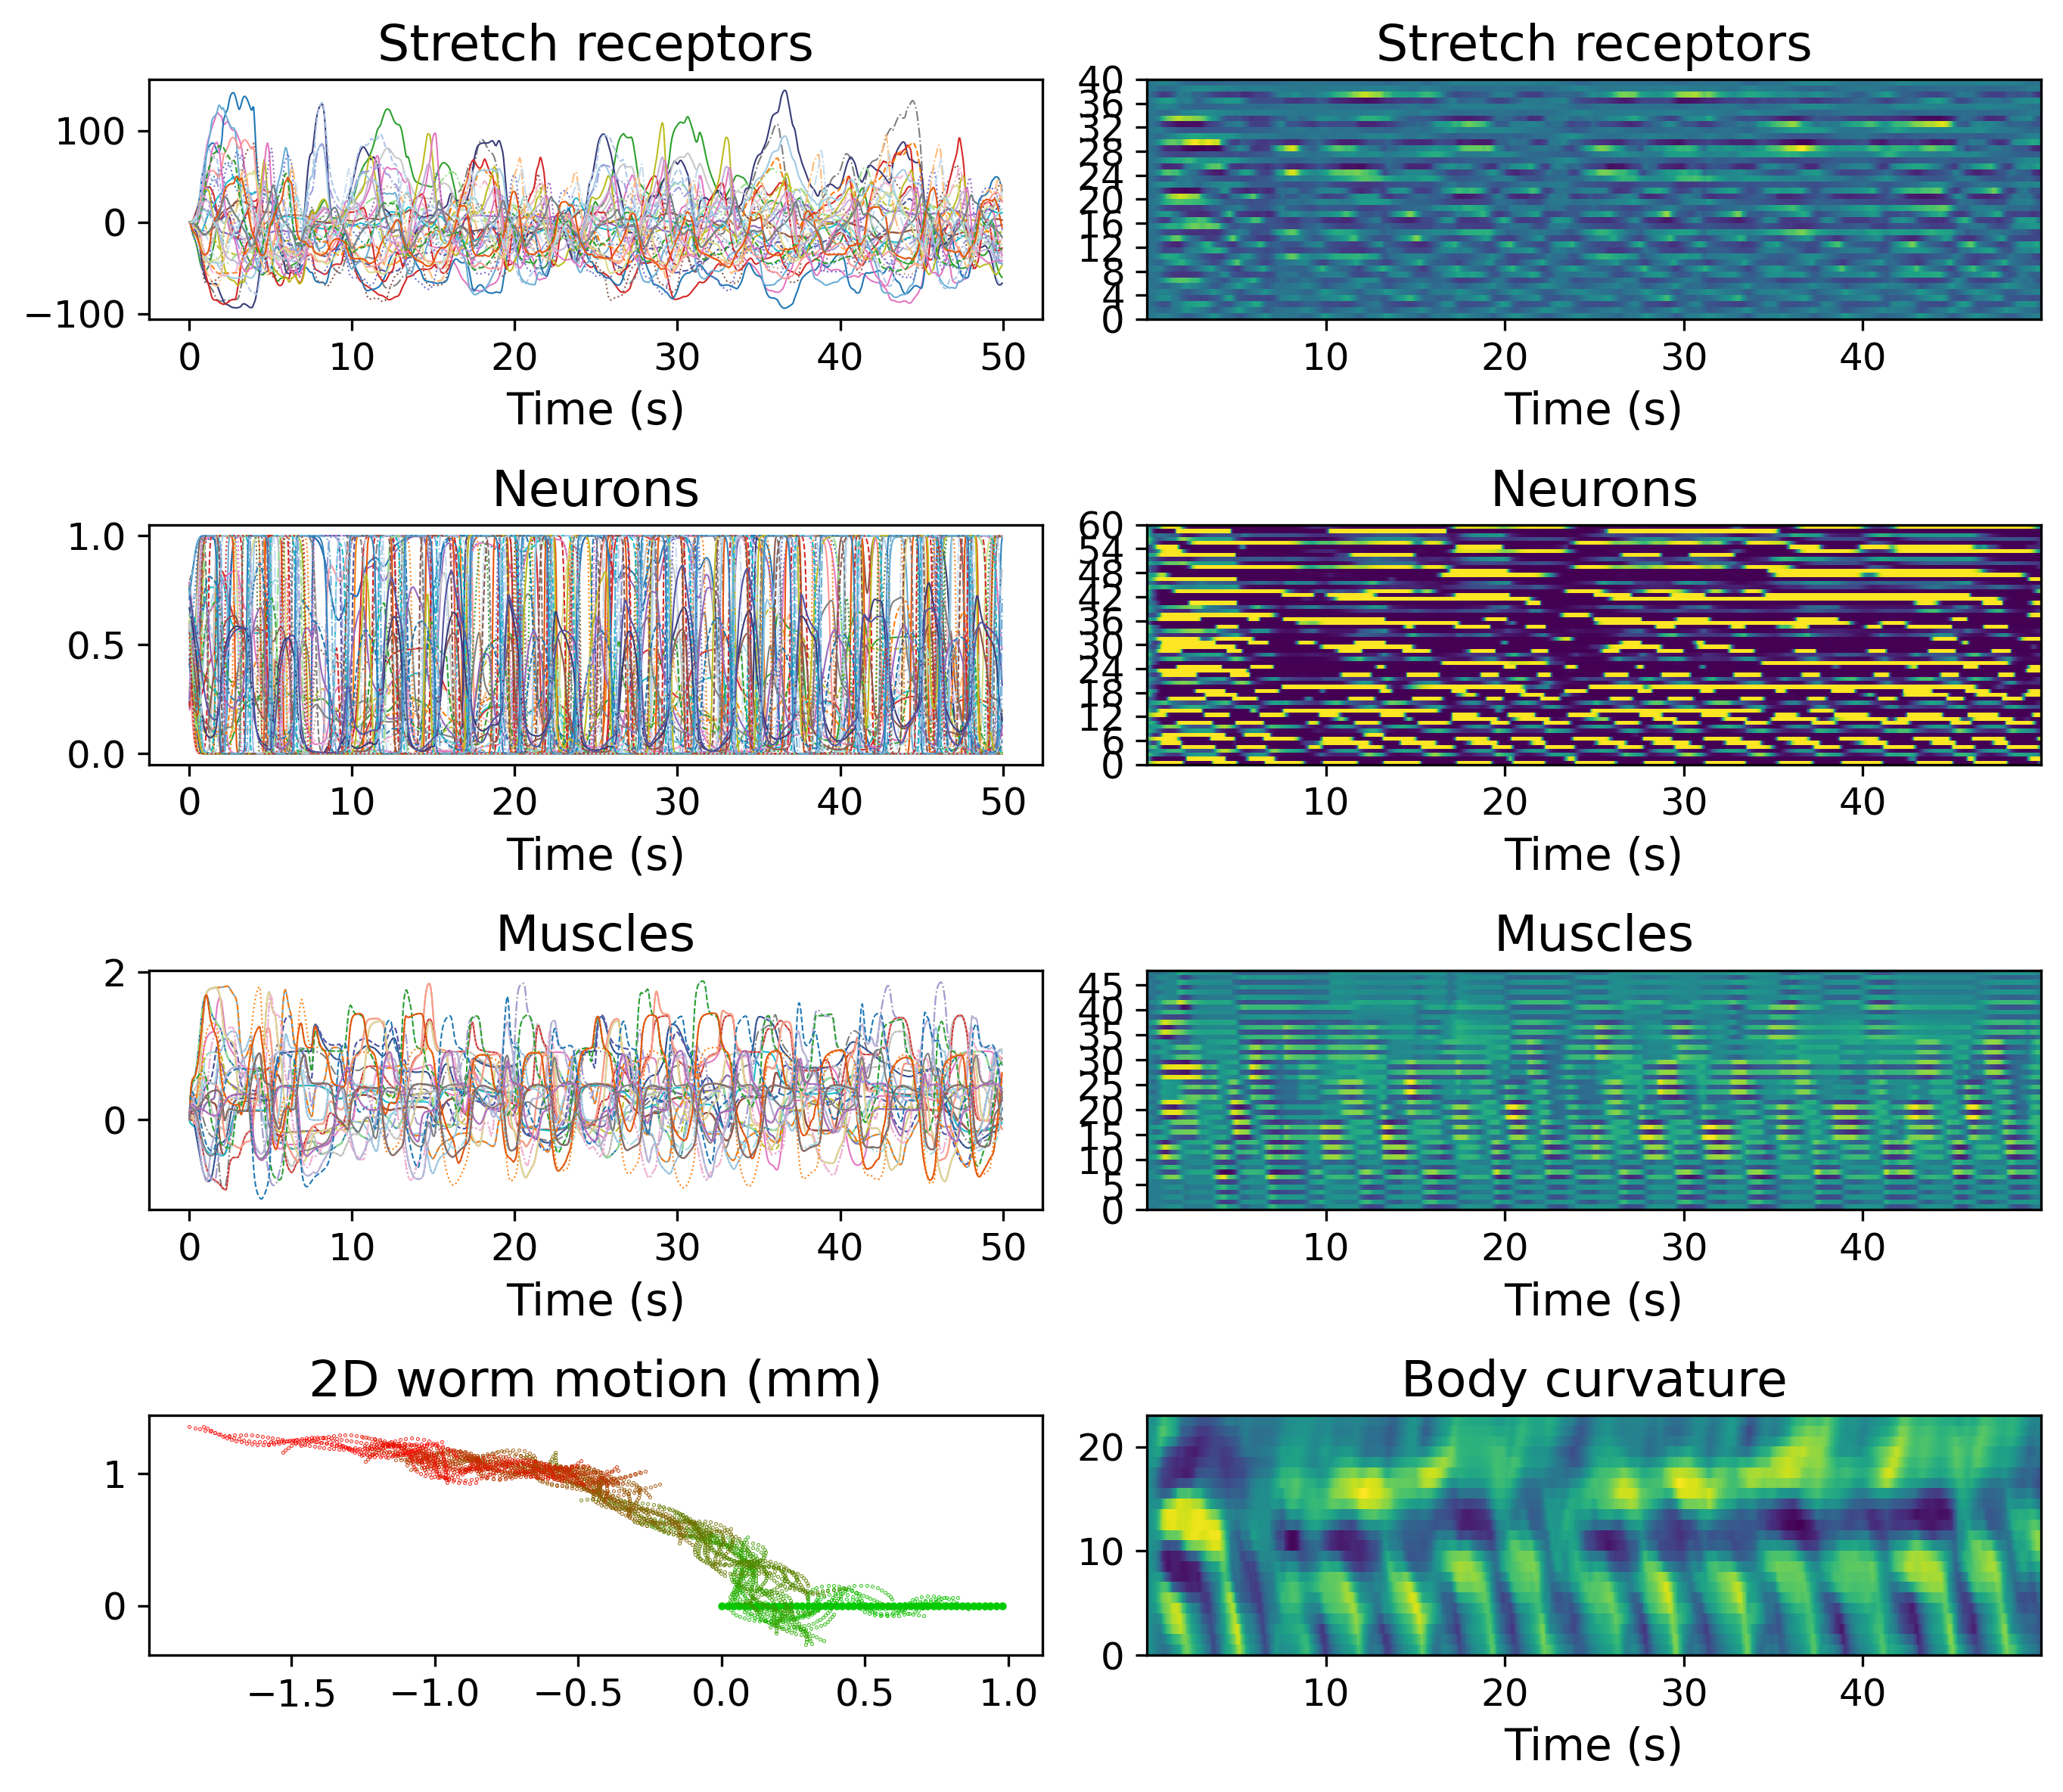

In [12]:
from IPython.display import Image, JSON
Image(filename=outputFolderName + '/ExampleActivity.png')

Display worm motion in larger plot:

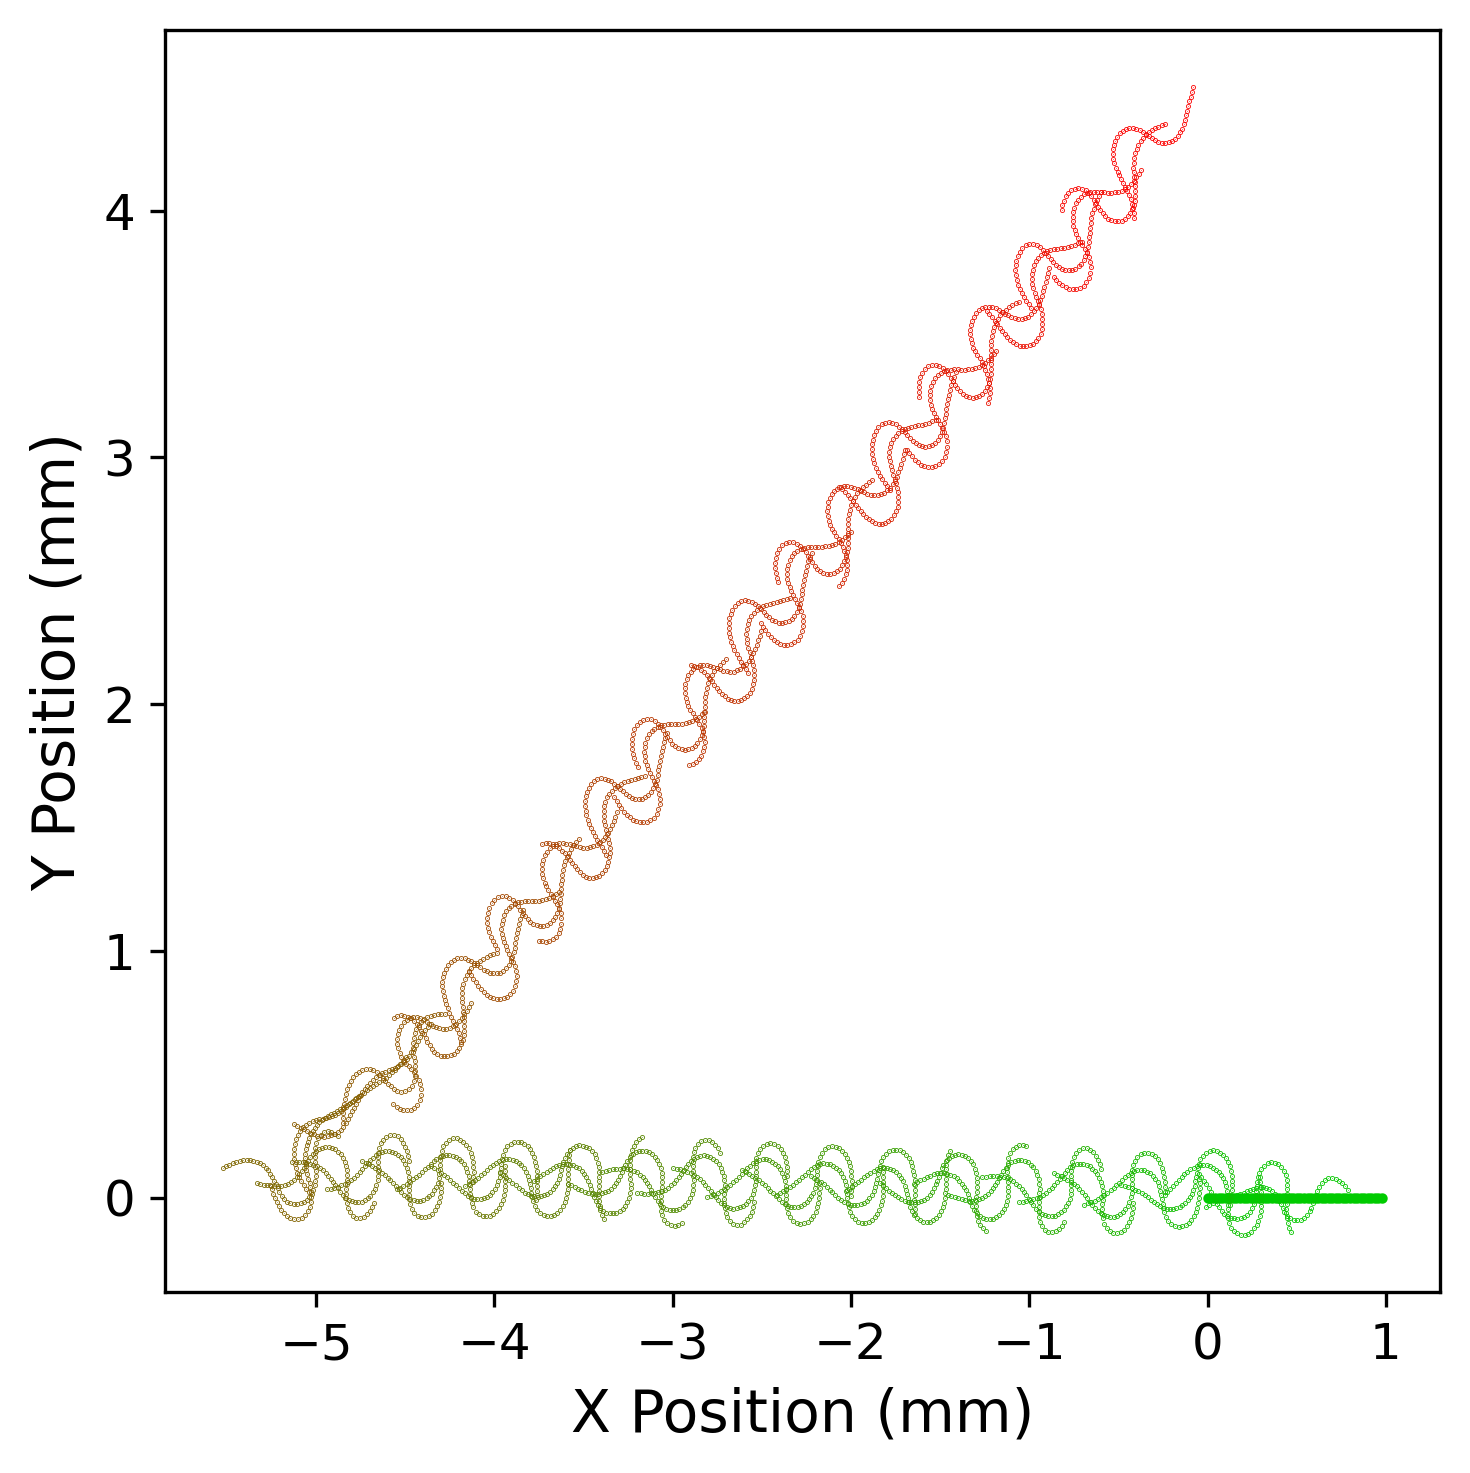

In [137]:
Image(filename=outputFolderName + '/Motion.png')

In [8]:
args['doEvol'] = False 
args['modelName'] ="W2DSR" #rerun using the generic json loaded model
run(**args)
#the ExampleActivity.png and Motion.png figures must be reloaded above to see results

Directory 'notebooks/example_CE2' already exists and the simulation results will be overwritten.
Parameter sr_type not found in worm_data.json
Parameter ab_output_level not found in worm_data.json
Parameter random_initial_state not found in worm_data.json
Parameter do_orig_musc_input not found in worm_data.json
Parameter do_orig_sr_input not found in worm_data.json

  Running Worm2D v0.1.0 with the following command:
['Worm2D/main_osc', '--do_reverse', '2', '--sr_type', 'None', '--ab_output_level', '1', '--random_initial_state', '1', '--avg_speed', '0.0001', '--fit_type', '0', '--do_orig_musc_input', '0', '--do_orig_sr_input', '0', '--sr_zero_gains_type', '1', '--do_legacy', '0', '-R', '272283', '--population_size', '16', '--max_generations', '5', '-sd', '50', '-st', '0', '--doevol', '0', '--checkpoint_interval', '5', '--donml', '0', '--folder', 'notebooks/example_CE2', '--modelname', 'W2DSR', '-docpt', '1', '--evo_type', 'EvoCE']
Starting Worm2D v0.1.0
jsonfile notebooks/example_CE2/w

In [10]:
args['doEvol'] = True 
args['maxGens']=5
args['modelName'] ="W2DSR" #add five more generations using the generic json loaded model
run(**args)
#the ExampleActivity.png and Motion.png figures must be reloaded above to see results

Directory 'notebooks/example_CE2' already exists and all the contents will be overwritten.
Parameter sr_type not found in worm_data.json
Parameter ab_output_level not found in worm_data.json
Parameter random_initial_state not found in worm_data.json
Parameter do_orig_musc_input not found in worm_data.json
Parameter do_orig_sr_input not found in worm_data.json

  Running Worm2D v0.1.0 with the following command:
['Worm2D/main_osc', '--do_reverse', '2', '--sr_type', 'None', '--ab_output_level', '1', '--random_initial_state', '1', '--avg_speed', '0.0001', '--fit_type', '0', '--do_orig_musc_input', '0', '--do_orig_sr_input', '0', '--sr_zero_gains_type', '1', '--do_legacy', '0', '-R', '272283', '--population_size', '16', '--max_generations', '5', '-sd', '50', '-st', '0', '--doevol', '1', '--checkpoint_interval', '5', '--donml', '0', '--folder', 'notebooks/example_CE2', '--modelname', 'W2DSR', '-docpt', '1', '--evo_type', 'EvoCE']
Starting Worm2D v0.1.0
jsonfile notebooks/example_CE2/worm_da

Examine the structure of the current worm in JSON format.

In [133]:
JSON(filename=outputFolderName + '/worm_data_worm.json')

<IPython.core.display.JSON object>

Load json file to examine it and potentially make modifications:

In [134]:
import json
with open(outputFolderName + '/worm_data_worm.json') as json_file:
    json_data = json.load(json_file)

Examine the evolvable parameters and their allowed ranges:

In [135]:
print(json.dumps(json_data['Evolvable'], indent=2))

{
  "value": [
    {
      "ind": 1,
      "val1": 0.0,
      "val2": 200.0
    },
    {
      "ind": 2,
      "val1": 0.0,
      "val2": 200.0
    },
    {
      "ind": 3,
      "val1": -16.0,
      "val2": 16.0
    },
    {
      "ind": 4,
      "val1": -16.0,
      "val2": 16.0
    },
    {
      "ind": 5,
      "val1": -16.0,
      "val2": 16.0
    },
    {
      "ind": 6,
      "val1": -16.0,
      "val2": 16.0
    },
    {
      "ind": 7,
      "val1": -16.0,
      "val2": 16.0
    },
    {
      "ind": 8,
      "val1": -16.0,
      "val2": 16.0
    },
    {
      "ind": 9,
      "val1": 0.0,
      "val2": 16.0
    },
    {
      "ind": 10,
      "val1": 0.0,
      "val2": 16.0
    },
    {
      "ind": 11,
      "val1": -16.0,
      "val2": 0.0
    },
    {
      "ind": 12,
      "val1": -16.0,
      "val2": 0.0
    },
    {
      "ind": 13,
      "val1": 0.0,
      "val2": 2.0
    },
    {
      "ind": 14,
      "val1": 0.0,
      "val2": 2.0
    },
    {
      "ind": 15,
     

In [112]:
print(json_data['Evolvable']["value"][0])

{'ind': 1, 'name': 'Stretch receptor_SR_A_gain', 'val1': 0.0, 'val2': 200.0}


Increase minimum possible value for the SR A gain:

In [113]:
json_data['Evolvable']["value"][0]['val1']=100.0
print(json_data['Evolvable']["value"][0])

{'ind': 1, 'name': 'Stretch receptor_SR_A_gain', 'val1': 100.0, 'val2': 200.0}


Save the modified json data:

In [114]:
with open(outputFolderName + '/worm_data_worm.json', "w") as f:
    json.dump(json_data, f)

Evolve further using this new range:

Directory 'notebooks/example_CE2' already exists and all the contents will be overwritten.
Parameter not found in worm_data.json
Parameter not found in worm_data.json
Parameter not found in worm_data.json
Parameter not found in worm_data.json
Parameter not found in worm_data.json
Parameter not found in worm_data.json
['Worm2D/main_osc', '--doReverse', '2', '--SRType', 'None', '--AB_output_level', '1', '--randomInitialState', '1', '--AvgSpeed', '0.0001', '--fitType', '0', '--doOrigMuscInput', '0', '--doOrigSRInput', '0', '--SRZeroGainsType', '1', '--doLegacy', '0', '-R', '272283', '-p', '16', '-d', '24.0', '-t', '8.0', '--maxgens', '5', '-sd', '50', '-st', '0', '--doevol', '1', '-cpt', '5', '--dorandinit', '0', '--donml', '0', '--folder', 'notebooks/example_CE2', '--modelname', 'W2DSR', '--domusc', '0', '-docpt', '1', '--evoType', 'EvoCE']
jsonfile notebooks/example_CE2/worm_data_worm.json
phengen 117.69 100 200
phengen 180.012 0 200
phengen 2.14289 -16 16
phengen -0.487029 -16 16
pheng

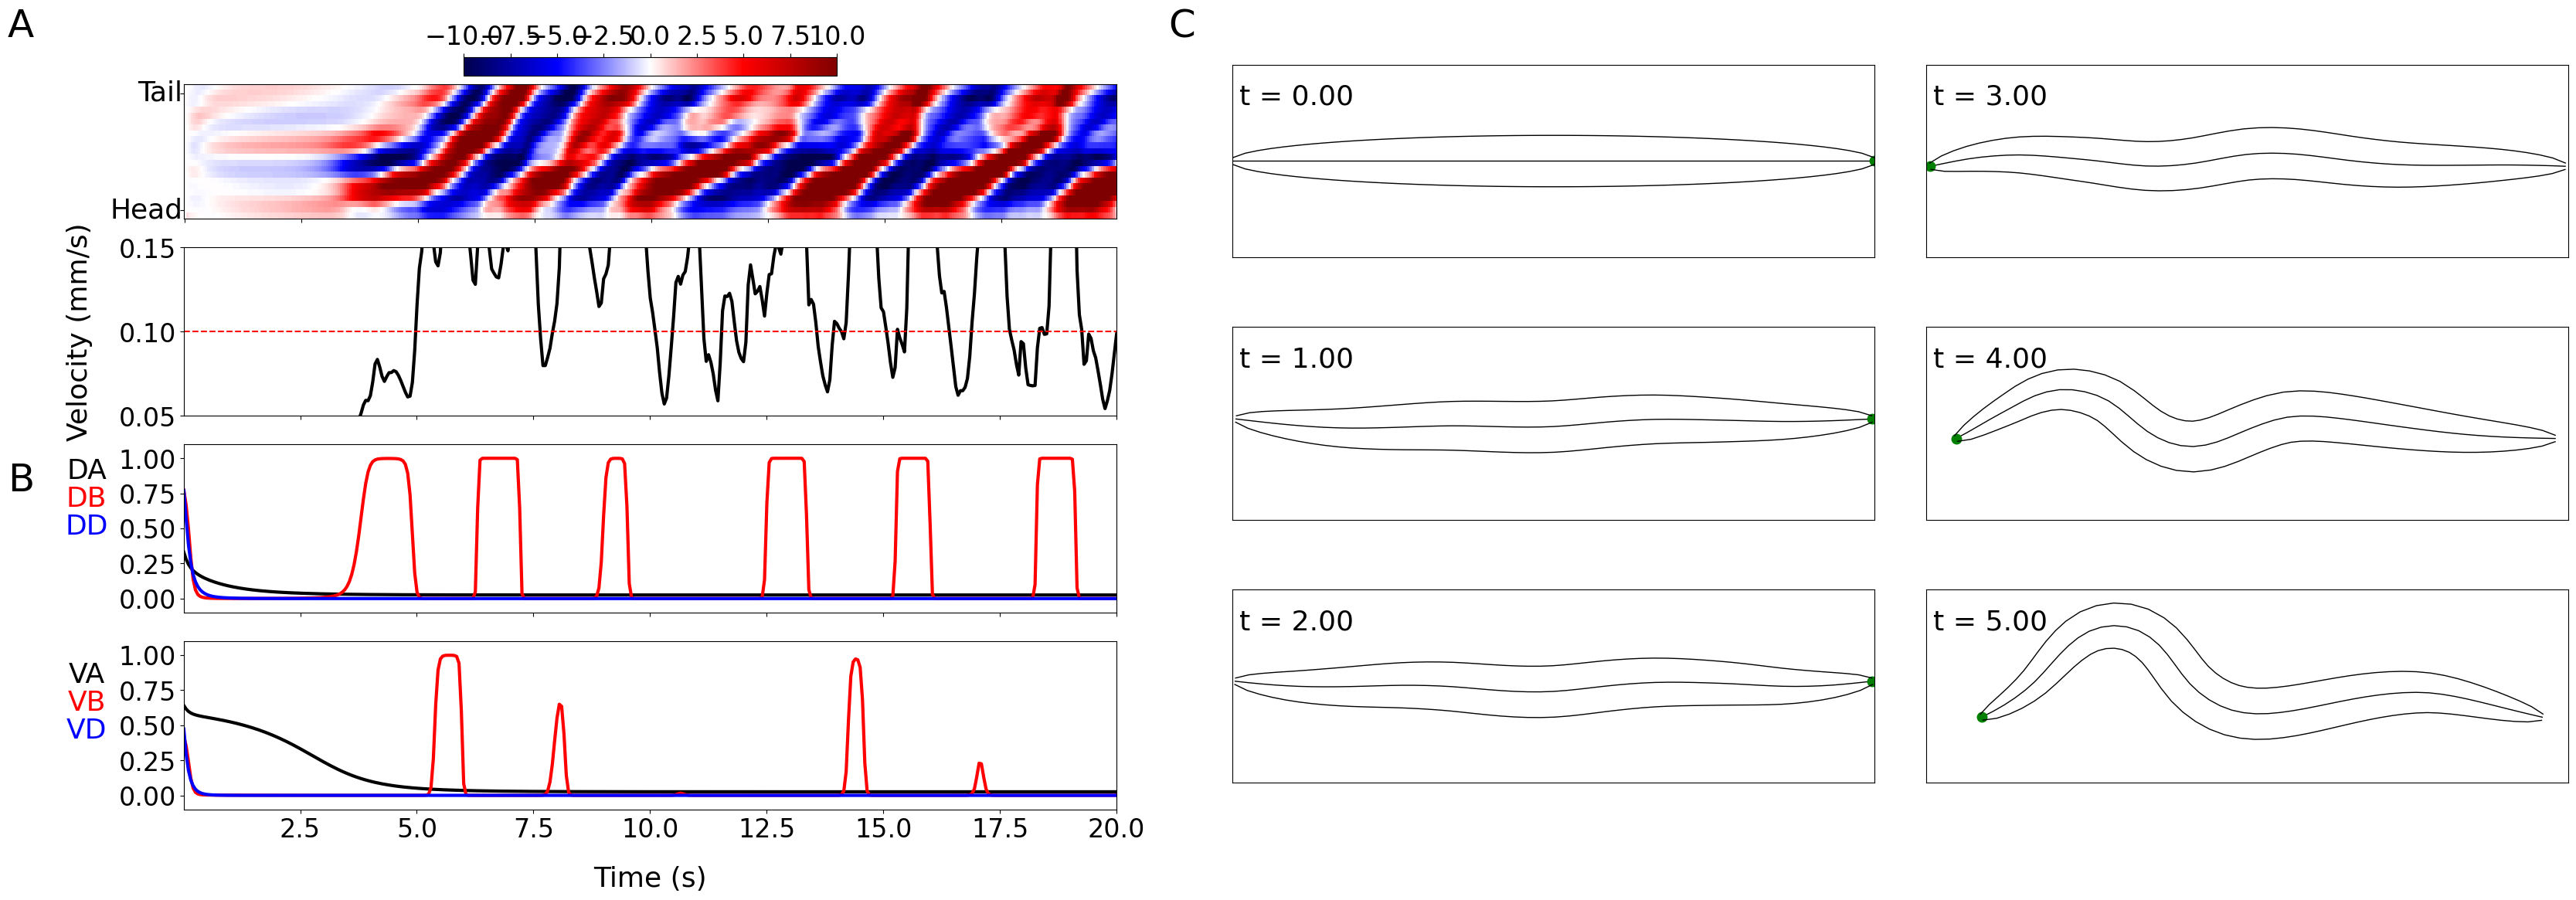

In [115]:
args['doEvol'] = True 
args['maxGens']=5
args['modelName'] ="W2DSR" #add five more generations using the generic json loaded model
run(**args)
#the ExampleActivity.png and Motion.png figures must be reloaded above to see results